In [48]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score,f1_score
import joblib


In [ ]:
x_test=pd.read_csv("test_loan.csv")
x_test.info()
x_test.shape

In [ ]:
x_train=pd.read_csv("train_loan.csv")
x_train.info()

In [ ]:
x_train.head()

In [ ]:
x_test.head()

In [6]:
x_train=x_train.drop(['Loan_ID','Gender'],axis=1)
x_test=x_test.drop(['Loan_ID','Gender'],axis=1)

In [ ]:
x_train.head()

In [ ]:
print(x_test['Married'].unique(),x_test['Education'].unique(),x_test['Self_Employed'].unique(),x_test['Property_Area'].unique())
print(x_train['Married'].unique(),x_train['Education'].unique(),x_train['Self_Employed'].unique(),x_train['Property_Area'].unique())
print(x_train.isna().sum())
print(x_train.shape,x_test.shape)
x_train=x_train.dropna()
x_test=x_test.dropna()
x_train['Dependents']=x_train['Dependents'].replace('3+','3')
x_test['Dependents']=x_test['Dependents'].replace('3+','3')
x_train['Dependents']=x_train['Dependents'].astype(int)
x_test['Dependents']=x_test['Dependents'].astype(int)
print(x_train.shape,x_test.shape)


In [ ]:
le_m=LabelEncoder()
x_train['Married']=le_m.fit_transform(x_train['Married'])
x_test['Married']=le_m.transform(x_test['Married'])
le_e=LabelEncoder()
x_train['Education']=le_e.fit_transform(x_train['Education'])
x_test['Education']=le_e.transform(x_test['Education'])
le_se=LabelEncoder()
x_train['Self_Employed']=le_se.fit_transform(x_train['Self_Employed'])
x_test['Self_Employed']=le_se.transform(x_test['Self_Employed'])
y_train=x_train['Loan_Status']
le_o=LabelEncoder()
y_train=le_o.fit_transform(y_train)
x_train=x_train.drop('Loan_Status',axis=1)
x_train.head()
y_train[:5]

In [10]:
ohe=OneHotEncoder()
pa_train=ohe.fit_transform(x_train[['Property_Area']]).toarray()
pa_test=ohe.transform(x_test[['Property_Area']]).toarray()

In [11]:
pa_train=pd.DataFrame(pa_train,columns=ohe.get_feature_names_out(['Property_Area']),index=x_train.index)
pa_test=pd.DataFrame(pa_test,columns=ohe.get_feature_names_out(['Property_Area']),index=x_test.index)
x_train = x_train.drop('Property_Area', axis=1)
x_test = x_test.drop('Property_Area', axis=1)
train_df=pd.concat([x_train,pa_train],axis=1)
test_df=pd.concat([x_test,pa_test],axis=1)

In [19]:
train_x,test_x,train_y,test_y=train_test_split(train_df,y_train,test_size=0.2,random_state=20)

In [22]:
dt=DecisionTreeClassifier()
dt.fit(train_x,train_y)
y_pred=dt.predict(test_x)

In [30]:
print(classification_report(test_y,y_pred))
print(f1_score(test_y,y_pred),accuracy_score(test_y,y_pred))

              precision    recall  f1-score   support

           0       0.65      0.68      0.67        38
           1       0.80      0.77      0.78        61

    accuracy                           0.74        99
   macro avg       0.72      0.73      0.72        99
weighted avg       0.74      0.74      0.74        99

0.7833333333333333 0.7373737373737373


[Text(0.38671875, 0.9705882352941176, 'x[8] <= 0.5\ngini = 0.414\nsamples = 393\nvalue = [115, 278]'),
 Text(0.109375, 0.9117647058823529, 'x[5] <= 8115.0\ngini = 0.229\nsamples = 53\nvalue = [46, 7]'),
 Text(0.248046875, 0.9411764705882353, 'True  '),
 Text(0.09375, 0.8529411764705882, 'x[6] <= 488.0\ngini = 0.204\nsamples = 52\nvalue = [46, 6]'),
 Text(0.078125, 0.7941176470588235, 'x[4] <= 4249.5\ngini = 0.177\nsamples = 51\nvalue = [46, 5]'),
 Text(0.046875, 0.7352941176470589, 'x[6] <= 91.5\ngini = 0.057\nsamples = 34\nvalue = [33, 1]'),
 Text(0.03125, 0.6764705882352942, 'x[5] <= 1233.0\ngini = 0.278\nsamples = 6\nvalue = [5, 1]'),
 Text(0.015625, 0.6176470588235294, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.046875, 0.6176470588235294, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.0625, 0.6764705882352942, 'gini = 0.0\nsamples = 28\nvalue = [28, 0]'),
 Text(0.109375, 0.7352941176470589, 'x[4] <= 5392.5\ngini = 0.36\nsamples = 17\nvalue = [13, 4]'),
 Text(0.09375, 

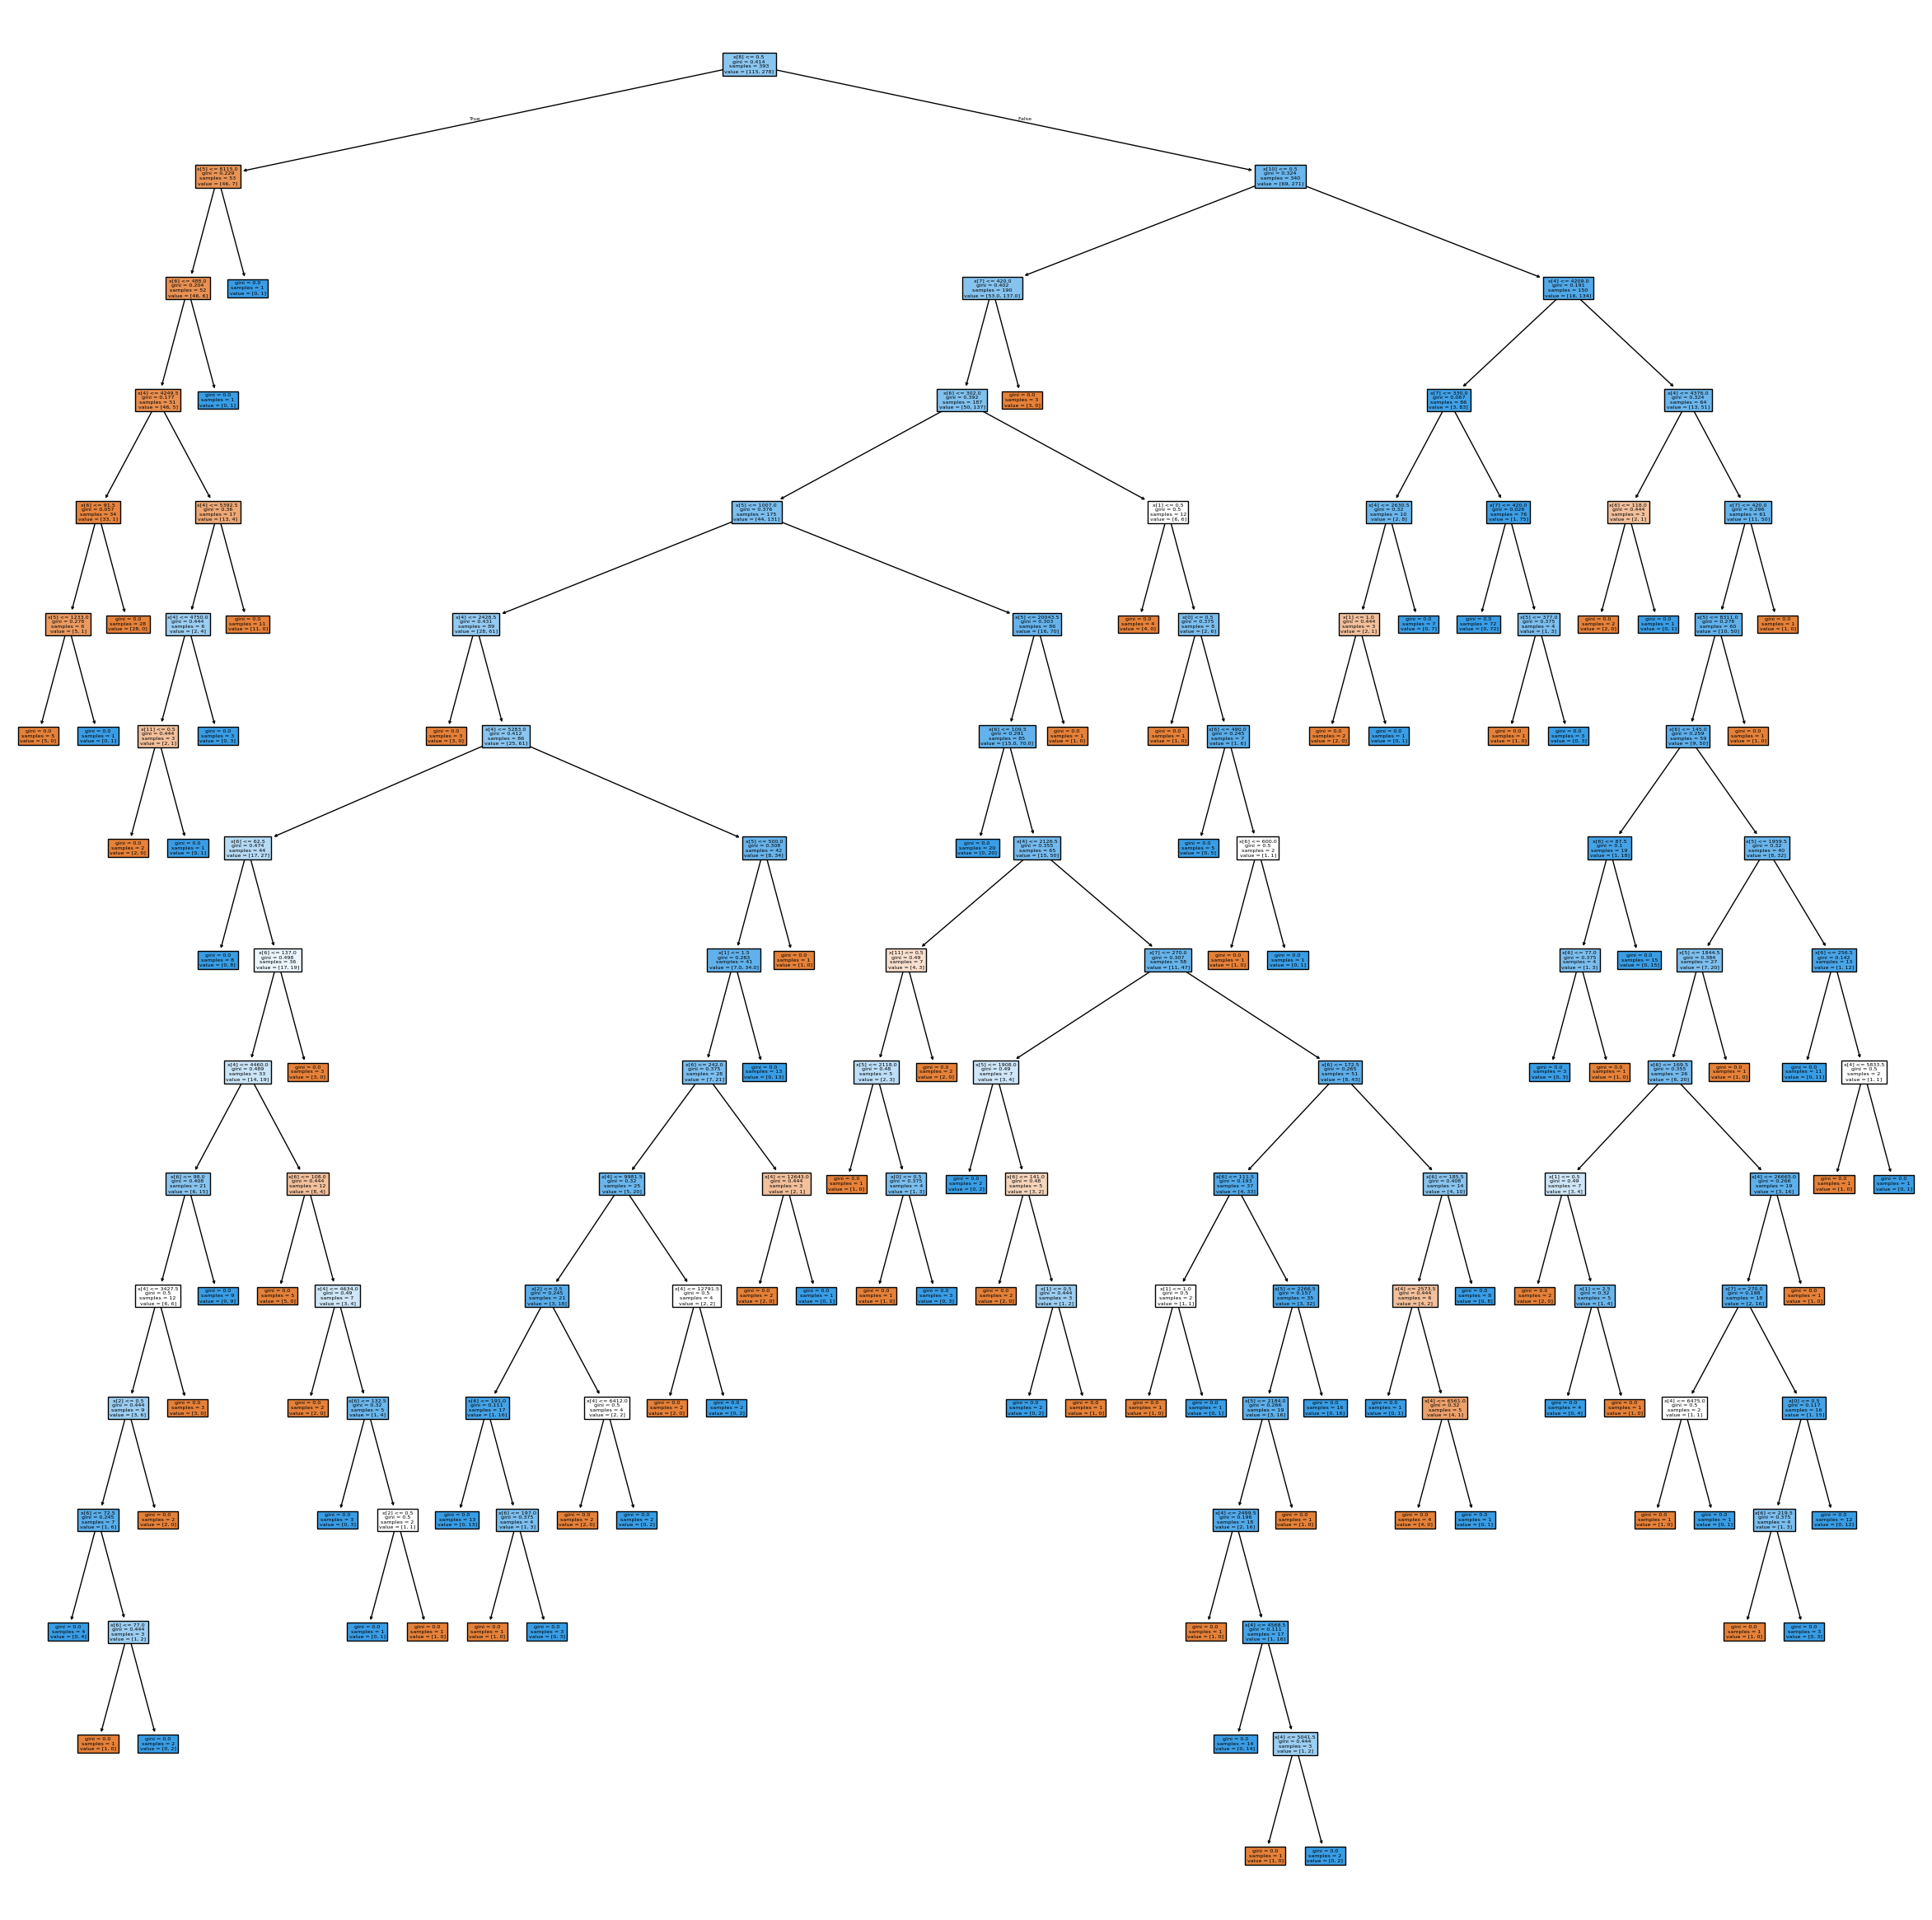

In [ ]:
plt.figure(figsize=(30,30))
tree.plot_tree(dt,filled=True)

In [26]:
rf=RandomForestClassifier()
rf.fit(train_x,train_y)
yr_pred=rf.predict(test_x)

In [29]:
print(classification_report(test_y,yr_pred))
print(f1_score(test_y,yr_pred),accuracy_score(test_y,yr_pred))

              precision    recall  f1-score   support

           0       0.81      0.58      0.68        38
           1       0.78      0.92      0.84        61

    accuracy                           0.79        99
   macro avg       0.80      0.75      0.76        99
weighted avg       0.79      0.79      0.78        99

0.8421052631578947 0.7878787878787878


In [32]:
param= {
    'n_estimators':[50,100,200],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5],
}

In [33]:
op=GridSearchCV(RandomForestClassifier(),param,cv=5,scoring='f1')
op.fit(train_x,train_y)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='f1')

In [ ]:
op.best_params_

In [37]:
oprf=RandomForestClassifier(max_depth=5,min_samples_split=2,n_estimators=100)
oprf.fit(train_x,train_y)

RandomForestClassifier(max_depth=5)

In [40]:
yop_pred=oprf.predict(test_x)
print(f1_score(test_y,yop_pred),accuracy_score(test_y,yop_pred))
print(classification_report(test_y,yop_pred))

0.8633093525179856 0.8080808080808081
              precision    recall  f1-score   support

           0       0.95      0.53      0.68        38
           1       0.77      0.98      0.86        61

    accuracy                           0.81        99
   macro avg       0.86      0.75      0.77        99
weighted avg       0.84      0.81      0.79        99



our tuned RF is performing better than DT and untuned RF so Lets use tuned RF as final model

In [43]:
final_model=RandomForestClassifier(max_depth=5,min_samples_split=2,n_estimators=100)
final_model.fit(train_df,y_train)

RandomForestClassifier(max_depth=5)

In [ ]:
final_model.predict(test_df)

In [49]:

joblib.dump(final_model, "loan_model.pkl")
print("Model saved successfully!")

Model saved successfully!
